In [1]:
import numpy as np
import pandas as pd
from src.processing import calculate_fitness, find_pareto_front
from src.visualization import display_pareto_front, display_fitness_landscape_with_pareto

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['lines.linewidth'] = 0.5


In [2]:
total_records = 10000000

# Parametrizar todas as equações por total_records
# Proporções calculadas com base em total_records = 10,000,000
equations1 = [
    lambda x: (x/(total_records * 0.05))**2 / 70,       # 500000 = total_records/20
    lambda x: 10 * np.cos(x/(total_records * 3)),       # 30000000 = total_records*3
    lambda x:  7 * np.cos(x/(total_records * 1)),       # 10000000 = total_records*1
    lambda x:  4 * np.cos(x/(total_records * 0.4)),     # 4000000 = total_records*0.4
    lambda x:  5 * np.cos(x/(total_records * 0.1)),     # 1000000 = total_records/10
    lambda x:  5 * np.cos(x/(total_records * 0.05)),    # 500000 = total_records/20
    lambda x:  4 * np.sin(x/(total_records * 0.01)),    # 100000 = total_records/100
    lambda x:  3 * np.cos(x/(total_records * 0.0025)),  # 25000 = total_records/400
    lambda x:  2 * np.cos(x/(total_records * 2 * 0.0004)),  # 4000 = total_records/2500
    lambda x:      np.sin(x/(total_records * 2 * 0.0002)),  # 2000 = total_records/5000
    lambda x: np.maximum(0, 3 * np.cos(2.3+ (x/(total_records * 0.001)))),  # 10000 = total_records/1000
    lambda x: np.maximum(0, 3 * np.sin(1  + (x/(total_records * 0.001)))),  # 10000 = total_records/1000
    lambda x: 5,
]

equations2 = [
#    lambda x: (x/(total_records * 0.1))**2 / 140,       # 500000 = total_records/20
    lambda x: (5**(-x/total_records))*3,
    lambda x: 10 * np.sin(x/(total_records * 3)),       # 30000000 = total_records*3
    lambda x:  7 * np.sin(x/(total_records * 1)),       # 10000000 = total_records*1
    lambda x:  2 * np.sin(x/(total_records * 0.4)),     # 4000000 = total_records*0.4
    lambda x:  2 * np.sin(x/(total_records * 0.2)),     # 2000000 = total_records/5
    lambda x:  2 * np.sin(x/(total_records * 0.1)),     # 1000000 = total_records/10
    lambda x:  2 * np.cos(x/(total_records * 0.03)),    # 300000 = total_records*0.03
    lambda x:  2 * np.cos(x/(total_records * 0.005)),   # 50000 = total_records/200
    lambda x:      np.sin(x/(total_records * 0.002)),   # 20000 = total_records/500
    lambda x:      np.cos(x/(total_records * 2 * 0.0008)),  # 8000 = total_records/1250
    lambda x: np.minimum(0, 3 * np.cos(2.3+ (x/(total_records * 0.001)))),  # 10000 = total_records/1000
    lambda x: np.minimum(0, 3 * np.sin(1  + (x/(total_records * 0.001)))),  # 10000 = total_records/1000
    lambda x: 5,
]

In [3]:
#### Criando dataframe com registros de 0 a 9999999
tamanho = len(str(total_records))-1
registros = np.arange(0, total_records, dtype=np.int32)
df = pd.DataFrame({'registro': registros})
print(f"Range: {registros[0]:,} até {registros[-1]:,}")

#### Calculando fitness de forma matricial
df = calculate_fitness(equations1, equations2, df)
df['fitness_full'] = df['fitness1'] + df['fitness2']
print(f"Colunas: {list(df.columns)}")

##### Encontrando a fronteira de Pareto verdadeira
#pareto_df = find_pareto_front(df)
#display_pareto_front(df, pareto_df)
#display_fitness_landscape_with_pareto(df, pareto_df)
#
##### Salvando resultados
#df.to_parquet('data/df.parquet')
#pareto_df.to_parquet('data/pareto_df.parquet')

Range: 0 até 9,999,999
Colunas: ['registro', 'eq1_0', 'eq1_1', 'eq1_2', 'eq1_3', 'eq1_4', 'eq1_5', 'eq1_6', 'eq1_7', 'eq1_8', 'eq1_9', 'eq1_10', 'eq1_11', 'eq1_12', 'eq2_0', 'eq2_1', 'eq2_2', 'eq2_3', 'eq2_4', 'eq2_5', 'eq2_6', 'eq2_7', 'eq2_8', 'eq2_9', 'eq2_10', 'eq2_11', 'eq2_12', 'fitness1', 'fitness2', 'fitness_full']


# df2 lab

In [4]:
df2 = df.copy()
df2['fitness1'] /= 2.5
df2['fitness2'] /= 1.1
#df2['fitness2'] = np.where(df2['fitness2'] > 15, df2['fitness2'], df2['fitness2'] + 0.3 * (15-df2['fitness2']))
df2

,registro,eq1_0,eq1_1,eq1_2,eq1_3,eq1_4,eq1_5,eq1_6,eq1_7,eq1_8,...,eq2_6,eq2_7,eq2_8,eq2_9,eq2_10,eq2_11,eq2_12,fitness1,fitness2,fitness_full
0,0,0.000000e+00,10.00000,7.000000,4.000000,5.000000,5.000000,0.000000,3.000000,2.000000,...,2.000000,2.000000,0.000000,1.000000,-1.998828,0.0,5,17.409765,10.001065,54.525585
1,1,5.714286e-14,10.00000,7.000000,4.000000,5.000000,5.000000,0.000040,3.000000,2.000000,...,2.000000,2.000000,0.000050,1.000000,-1.999052,0.0,5,17.409946,10.000911,54.525867
2,2,2.285714e-13,10.00000,7.000000,4.000000,5.000000,5.000000,0.000080,3.000000,2.000000,...,2.000000,2.000000,0.000100,1.000000,-1.999275,0.0,5,17.410127,10.000757,54.526150
3,3,5.142857e-13,10.00000,7.000000,4.000000,5.000000,5.000000,0.000120,3.000000,2.000000,...,2.000000,2.000000,0.000150,1.000000,-1.999499,0.0,5,17.410308,10.000603,54.526432
4,4,9.142857e-13,10.00000,7.000000,4.000000,5.000000,5.000000,0.000160,3.000000,2.000000,...,2.000000,2.000000,0.000200,1.000000,-1.999723,0.0,5,17.410488,10.000449,54.526714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999995,9999995,5.714280e+00,9.44957,3.782119,-3.204571,-4.195371,2.040456,-2.025635,-1.576400,1.875640,...,-0.679392,0.974201,-0.467551,-0.984332,-2.974121,0.0,5,7.587828,8.020098,27.791677
9999996,9999996,5.714281e+00,9.44957,3.782118,-3.204572,-4.195369,2.040447,-2.025601,-1.576297,1.875726,...,-0.679399,0.974236,-0.467595,-0.984343,-2.974082,0.0,5,7.587944,8.020108,27.791978
9999997,9999997,5.714282e+00,9.44957,3.782118,-3.204573,-4.195366,2.040438,-2.025566,-1.576195,1.875813,...,-0.679405,0.974271,-0.467639,-0.984354,-2.974043,0.0,5,7.588059,8.020119,27.792279
9999998,9999998,5.714283e+00,9.44957,3.782117,-3.204573,-4.195363,2.040429,-2.025532,-1.576093,1.875900,...,-0.679411,0.974305,-0.467683,-0.984365,-2.974003,0.0,5,7.588175,8.020129,27.792580


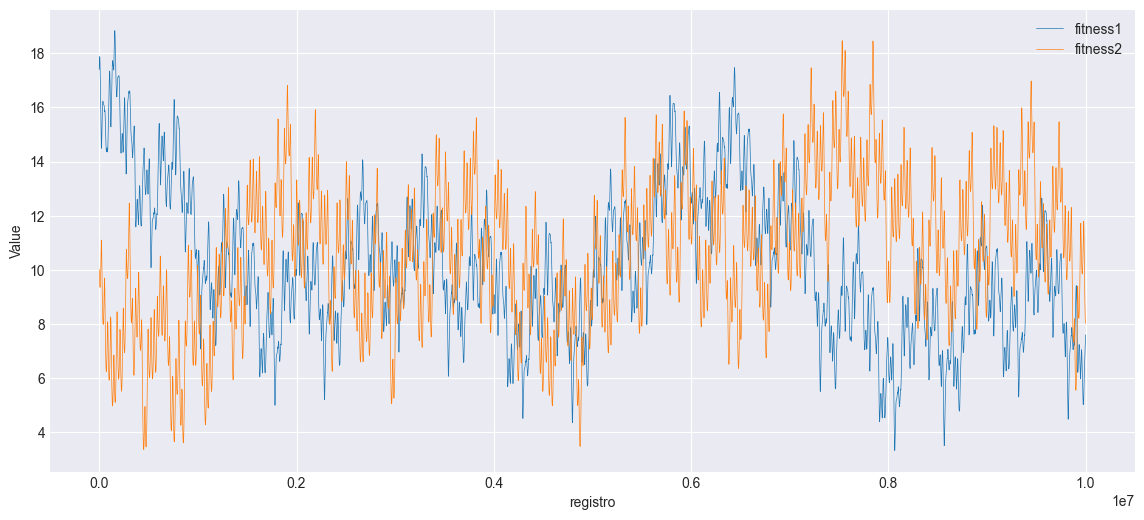

In [5]:
#plt.plot(df2['registro'], df2['log'], label='log')
plt.plot(df2['registro'], df2['fitness1'], label='fitness1')
plt.plot(df2['registro'], df2['fitness2'], label='fitness2')

plt.xlabel('registro')
plt.ylabel('Value')
plt.legend()
plt.show()

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 10,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 43,958 pontos.
Isso representa 0.4396% do espaço de busca.


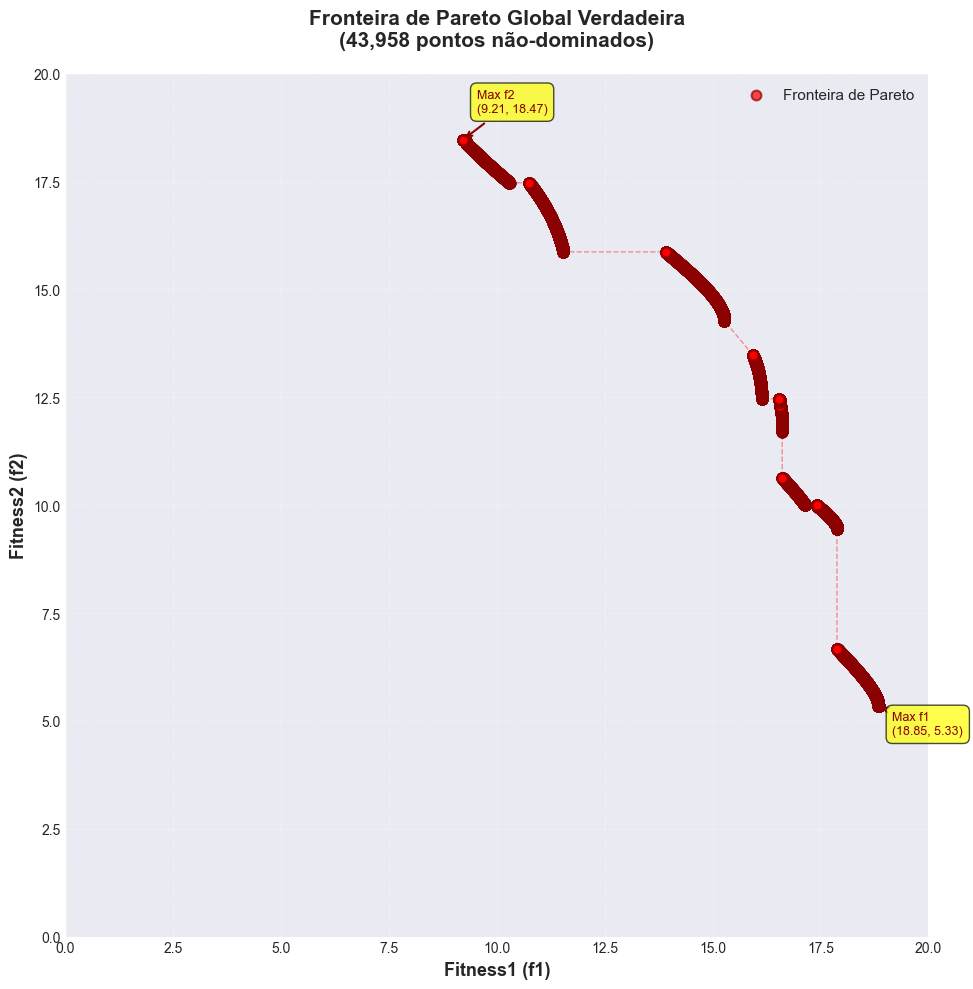


✅ Visualização concluída!


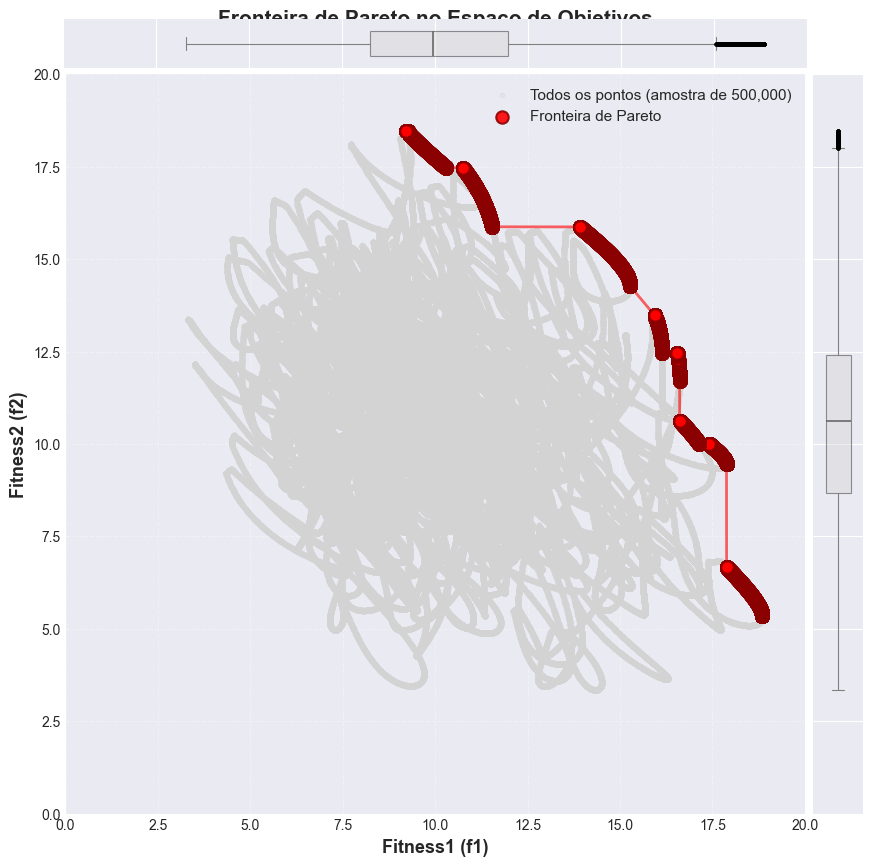

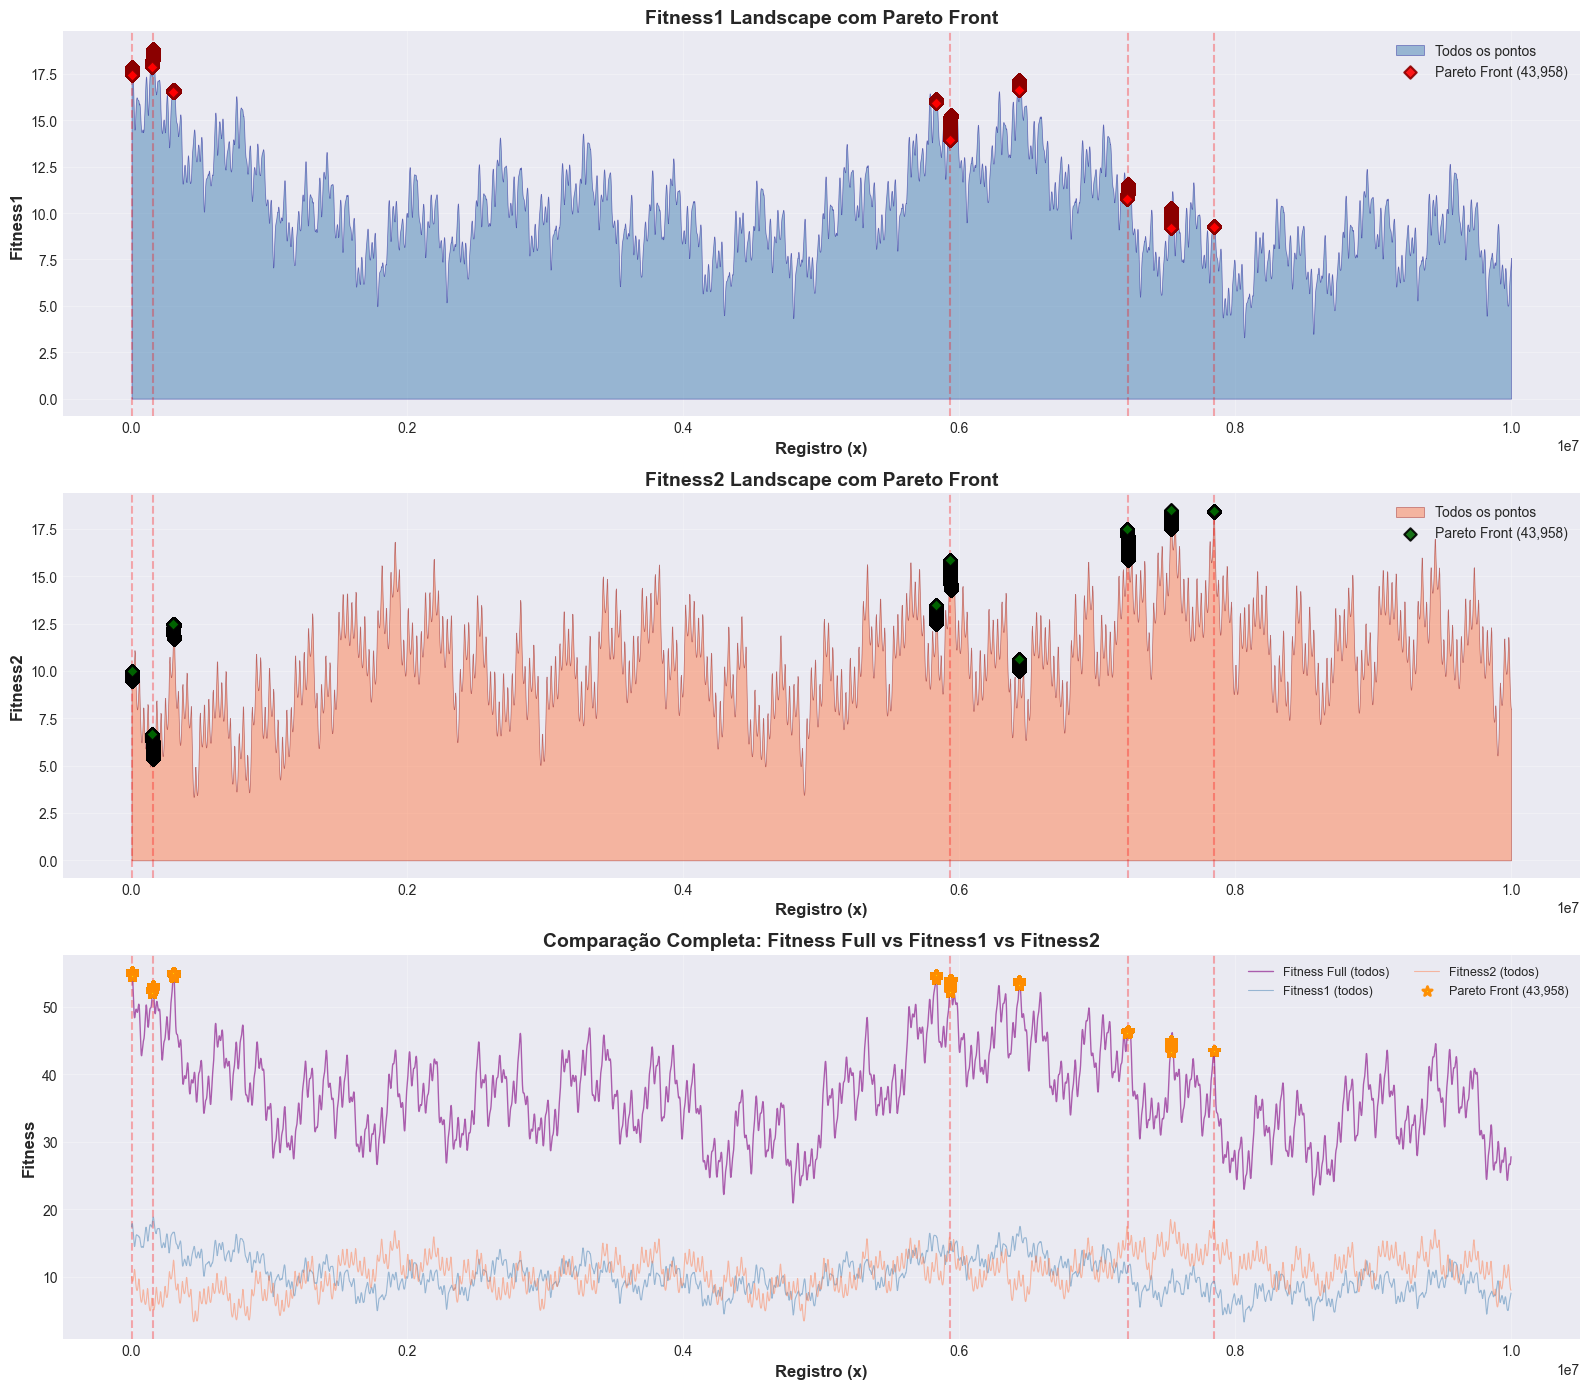

In [6]:
pareto_df2 = find_pareto_front(df2)
display_pareto_front(df2, pareto_df2)
display_fitness_landscape_with_pareto(df2, pareto_df2)

#df3 = df2.copy()
#df3['fitness1'] = 20 - df3['fitness1']
#df3['fitness2'] = 20 - df3['fitness2']
#
#pareto_df3 = df2.copy()
#pareto_df3['fitness1'] = 20 - pareto_df3['fitness1']
#pareto_df3['fitness2'] = 20 - pareto_df3['fitness2']
#
#display_pareto_front(df2, pareto_df3)